<a href="https://colab.research.google.com/github/qhtni/CB2330-project/blob/main/istg_this_better_be_the_last_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---

###**Project CB2330** *- Coral bleaching generalized linear mixed model: replacing calendar time with climate*

---

PRO1 — Coral bleaching GLMM: replacing calendar time with climate


Project card

The paper: Hughes et al. (2018), Spatial and temporal patterns of mass bleaching of corals in the Anthropocene.

The data object:One row per reef location per year (1980–2016), with severe bleaching coded as 0/1, region, global temperature anomaly, and Niño 3.4 anomaly.


The random variable chosen
$$
Y_{igt}\sim \mathrm{Bernoulli}(p_{igt}),
$$

where $$(Y_{igt}=1)$$ if reef $$i$$ in region \(g\) has severe bleaching in year $$(t\)$$, otherwise 0.

Paper-like model
$$
\mathrm{logit}(p_{igt}) = a_g + d_g t + u_i,
\qquad
u_i \sim N(0,\sigma^2_{\mathrm{reef}})
$$
Our climate model
$$
\boxed{
\mathrm{logit}(p_{igt})
=
a_g+b_gT_t+c_gN_t+u_i
}
$$
where $$(T_t\)$$ is centered global temperature anomaly and $$(N_t\)$$ is centered annual mean Niño 3.4 anomaly.
Parameters
- \(a_g\): regional baseline log-odds
- \(b_g\): regional temperature effect
- \(c_g\): regional Niño effect
- \(\sigma_{\mathrm{reef}}\): SD of persistent reef-to-reef variation
Forward simulation
1. Draw one reef effect \(u_i\sim N(0,\sigma^2)\) for each reef.
2. Compute bleaching probability.
3. Draw \(Y\sim\mathrm{Bernoulli}(p)\).
4. Repeat for all reef-years and repeat the whole experiment many times.
Backward fitting
Estimate parameters by maximizing the marginal likelihood.
What this adds
It tests whether measured climate variables explain severe bleaching better than calendar time alone.
Limitations
Global temperature anomaly and Niño 3.4 are not local reef heat-stress measurements; annual summaries lose seasonal extremes; the model omits recovery, local heat thresholds, and explicit temporal autocorrelation.

1. Setup
This notebook needs one CSV:
master_location_year.csv
Required columns:
location_id, region, year, t, severe, global_temp_anom_mean, nino34_anom_mean, temp_c, nino_c

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.special import expit, logsumexp
from numpy.polynomial.hermite import hermgauss

SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Ready.")

Ready.


2. Load the prepared reef-year table

In [ ]:
filename = "master_location_year.csv"

if not Path(filename).exists():
    try:
        from google.colab import files
        files.upload()
    except ImportError:
        pass

if not Path(filename).exists():
    raise FileNotFoundError("Upload master_location_year.csv and rerun this cell.")

master = pd.read_csv(filename)

print("Shape:", master.shape)
display(master.head())

Shape: (3700, 9)


,location_id,region,year,t,severe,global_temp_anom_mean,nino34_anom_mean,temp_c,nino_c
0,1,Australasia,1980,0,0,0.255833,-0.001667,-0.217995,0.030180
1,1,Australasia,1981,1,0,0.322500,-0.455833,-0.151329,-0.423986
2,1,Australasia,1982,2,0,0.139167,0.831667,-0.334662,0.863514
3,1,Australasia,1983,3,0,0.315000,0.306667,-0.158829,0.338514
4,1,Australasia,1984,4,0,0.155833,-0.664167,-0.317995,-0.632320


3. Data checks

In [ ]:
required_cols = [
    "location_id", "region", "year", "t", "severe",
    "global_temp_anom_mean", "nino34_anom_mean",
    "temp_c", "nino_c"
]

missing = [c for c in required_cols if c not in master.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

summary_table = pd.DataFrame({
    "quantity": [
        "reef locations",
        "years",
        "reef-year rows",
        "regions",
        "severe bleaching rows"
    ],
    "value": [
        master["location_id"].nunique(),
        master["year"].nunique(),
        len(master),
        master["region"].nunique(),
        int(master["severe"].sum())
    ]
})

display(summary_table)

print("Missing values:")
display(master[required_cols].isna().sum().to_frame("n_missing"))

,quantity,value
0,reef locations,100
1,years,37
2,reef-year rows,3700
3,regions,4
4,severe bleaching rows,299


Missing values:


,n_missing
location_id,0
region,0
year,0
t,0
severe,0
global_temp_anom_mean,0
nino34_anom_mean,0
temp_c,0
nino_c,0


4. The generative model in code
For one reef-year:
\[
\eta=a_g+b_gT+c_gN+u_i
\]
\[
p=\frac{1}{1+e^{-\eta}}
\]
\[
Y\sim \mathrm{Bernoulli}(p)
\]

In [ ]:
import numpy as np

def logistic(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
def simulate_bleaching(
    intercept,
    temp_effect,
    nino_effect,
    temp,
    nino,
    reef_effect,
    rng
):
    # linear predictor
    eta = (
        intercept
        + temp_effect * temp
        + nino_effect * nino
        + reef_effect
    )

    # convert log-odds to probability
    p = logistic(eta)

    # Bernoulli observation
    severe = rng.binomial(1, p)

    return severe, p

In [ ]:
rng = np.random.default_rng(42)

severe, p = simulate_bleaching(
    intercept=-3.0,
    temp_effect=4.0,
    nino_effect=0.5,
    temp=0.2,
    nino=0.3,
    reef_effect=0.1,
    rng=rng
)

print("Bleaching probability:", p)
print("Simulated severe bleaching:", severe)

Bleaching probability: 0.12455335818741639
Simulated severe bleaching: 0


5. Encode regions and reefs

In [ ]:
regions = list(master["region"].drop_duplicates())
region_to_index = {r: i for i, r in enumerate(regions)}
master["region_idx"] = master["region"].map(region_to_index)

reef_codes, reef_labels = pd.factorize(master["location_id"])
master["reef_idx"] = reef_codes

y = master["severe"].to_numpy(dtype=int)
region_idx = master["region_idx"].to_numpy(dtype=int)
reef_idx = master["reef_idx"].to_numpy(dtype=int)

temp = master["temp_c"].to_numpy(dtype=float)
nino = master["nino_c"].to_numpy(dtype=float)
time = master["t"].to_numpy(dtype=float)

n_regions = len(regions)
n_reefs = master["reef_idx"].nunique()

print("Regions:", regions)
print("Number of reefs:", n_reefs)

Regions: ['Australasia', 'Indian Ocean / Middle East', 'Pacific', 'West Atlantic']
Number of reefs: 100


6. Fit both GLMMs
The random reef effect is unobserved. During fitting, the likelihood averages over plausible values of the reef effect:
\[
L_i(\theta)
=
\int
P(Y_i\mid u_i,\theta)\,P(u_i\mid\sigma)\,du_i.
\]
The code below uses a small numerical approximation for this one-dimensional integral. This is only a fitting detail; it is not an extra biological assumption.

In [ ]:
N_QUAD = 15
gh_x, gh_w = hermgauss(N_QUAD)
log_gh_w = np.log(gh_w)

def bernoulli_loglik(y_i, eta):
    return (
        y_i * (-np.logaddexp(0, -eta))
        + (1 - y_i) * (-np.logaddexp(0, eta))
    )

def climate_neg_loglik(params):
    R = n_regions
    a = params[0:R]
    b = params[R:2*R]
    c = params[2*R:3*R]
    sigma = np.exp(params[3*R])

    total = 0.0

    for reef in range(n_reefs):
        mask = reef_idx == reef
        y_i = y[mask]
        g_i = region_idx[mask]
        temp_i = temp[mask]
        nino_i = nino[mask]

        terms = []

        for x, log_w in zip(gh_x, log_gh_w):
            u = np.sqrt(2.0) * sigma * x
            eta = (
                a[g_i]
                + b[g_i] * temp_i
                + c[g_i] * nino_i
                + u
            )
            terms.append(
                log_w + bernoulli_loglik(y_i, eta).sum()
            )

        total += logsumexp(terms) - 0.5 * np.log(np.pi)

    return -total

def time_neg_loglik(params):
    R = n_regions
    a = params[0:R]
    d = params[R:2*R]
    sigma = np.exp(params[2*R])

    total = 0.0

    for reef in range(n_reefs):
        mask = reef_idx == reef
        y_i = y[mask]
        g_i = region_idx[mask]
        t_i = time[mask]

        terms = []

        for x, log_w in zip(gh_x, log_gh_w):
            u = np.sqrt(2.0) * sigma * x
            eta = a[g_i] + d[g_i] * t_i + u
            terms.append(
                log_w + bernoulli_loglik(y_i, eta).sum()
            )

        total += logsumexp(terms) - 0.5 * np.log(np.pi)

    return -total

Fit the climate model

In [ ]:
R = n_regions

start_climate = np.concatenate([
    np.full(R, -3.0),
    np.full(R, 2.0),
    np.zeros(R),
    [np.log(0.25)]
])

fit_climate = minimize( #ok this was diff at first but the model failed to converge (but it was like kinda fine apparently)
    climate_neg_loglik,
    start_climate,
    method="L-BFGS-B",
    options={
        "maxiter": 3000,
        "ftol": 1e-10,
        "gtol": 1e-6
    }
)


print("Success:", fit_climate.success)
print("Message:", fit_climate.message)
print("Negative log-likelihood:", fit_climate.fun)

theta_climate = fit_climate.x
a_hat = theta_climate[0:R]
b_hat = theta_climate[R:2*R]
c_hat = theta_climate[2*R:3*R]
sigma_hat = np.exp(theta_climate[3*R])

climate_parameters = pd.DataFrame({
    "region": regions,
    "intercept": a_hat,
    "temperature_effect": b_hat,
    "nino_effect": c_hat
})

display(climate_parameters)
print("Reef random-effect SD:", sigma_hat)

Success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Negative log-likelihood: 898.073289568408


,region,intercept,temperature_effect,nino_effect
0,Australasia,-3.670398,7.778568,-1.005072
1,Indian Ocean / Middle East,-3.132560,5.964408,-0.079198
2,Pacific,-2.544340,2.588071,0.742970
3,West Atlantic,-2.384029,1.356134,0.391121


Reef random-effect SD: 0.264550916721139


initially The Python optimizer reported numerical precision loss near the optimum, but the fitted coefficients closely matched the independently fitted R glmer() model, supporting that the implementation reached the correct parameter region.

Fit the paper-like time model

In [ ]:
start_time = np.concatenate([
    np.full(R, -3.0),
    np.full(R, 0.05),
    [np.log(0.25)]
])

fit_time = minimize(
    time_neg_loglik,
    start_time,
    method="L-BFGS-B",
    options={
        "maxiter": 3000,
        "ftol": 1e-10,
        "gtol": 1e-6
    }
)

print("Success:", fit_time.success)
print("Message:", fit_time.message)
print("Negative log-likelihood:", fit_time.fun)

theta_time = fit_time.x
a_time_hat = theta_time[0:R]
d_time_hat = theta_time[R:2*R]
sigma_time_hat = np.exp(theta_time[2*R])

time_parameters = pd.DataFrame({
    "region": regions,
    "intercept": a_time_hat,
    "time_effect": d_time_hat
})

display(time_parameters)
print("Reef random-effect SD:", sigma_time_hat)

Success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Negative log-likelihood: 983.429865207725


,region,intercept,time_effect
0,Australasia,-4.702387,0.092276
1,Indian Ocean / Middle East,-4.041323,0.072807
2,Pacific,-3.185528,0.044812
3,West Atlantic,-2.289045,-0.000743


Reef random-effect SD: 0.18819118852653088


7. Compare the models

In [ ]:
loglik_climate = -fit_climate.fun
loglik_time = -fit_time.fun

k_climate = 3 * R + 1
k_time = 2 * R + 1
n = len(master)

comparison = pd.DataFrame({
    "model": ["Paper-like time GLMM", "Climate GLMM"],
    "n_parameters": [k_time, k_climate],
    "log_likelihood": [loglik_time, loglik_climate],
    "AIC": [
        2*k_time - 2*loglik_time,
        2*k_climate - 2*loglik_climate
    ],
    "BIC": [
        np.log(n)*k_time - 2*loglik_time,
        np.log(n)*k_climate - 2*loglik_climate
    ]
})

display(comparison)

,model,n_parameters,log_likelihood,AIC,BIC
0,Paper-like time GLMM,9,-983.429865,1984.859730,2040.804523
1,Climate GLMM,13,-898.073290,1822.146579,1902.955724


8. Forward Monte Carlo simulation
For every simulated experiment:
- draw one persistent reef effect \(u_i\)
- compute every reef-year probability
- draw every severe-bleaching outcome

In [ ]:
def simulate_dataset_climate(master, a, b, c, sigma, rng):
    sim = master.copy()

    reef_effects = {
        reef: rng.normal(0.0, sigma)
        for reef in sim["reef_idx"].unique()
    }

    u = sim["reef_idx"].map(reef_effects).to_numpy()
    g = sim["region_idx"].to_numpy(dtype=int)

    eta = (
        a[g]
        + b[g] * sim["temp_c"].to_numpy()
        + c[g] * sim["nino_c"].to_numpy()
        + u
    )

    p = expit(eta)

    sim["predicted_probability"] = p
    sim["simulated_severe"] = rng.binomial(1, p)

    return sim

sim_example = simulate_dataset_climate(
    master, a_hat, b_hat, c_hat, sigma_hat, rng
)

display(sim_example[
    ["location_id", "region", "year", "severe",
     "predicted_probability", "simulated_severe"]
].head(10))

,location_id,region,year,severe,predicted_probability,simulated_severe
0,1,Australasia,1980,0,0.003431,0
1,1,Australasia,1981,0,0.009045,0
2,1,Australasia,1982,0,0.000601,0
3,1,Australasia,1983,0,0.003985,0
4,1,Australasia,1984,0,0.003068,0
5,1,Australasia,1985,0,0.002496,0
6,1,Australasia,1986,0,0.001791,0
7,1,Australasia,1987,0,0.001906,0
8,1,Australasia,1988,0,0.025785,0
9,1,Australasia,1989,0,0.008708,0


Repeat the experiment 300 times

In [ ]:
N_SIMS = 300
simulation_summaries = []

for s in range(N_SIMS):
    sim = simulate_dataset_climate(
        master, a_hat, b_hat, c_hat, sigma_hat, rng
    )

    one = (
        sim.groupby(["region", "year"])["simulated_severe"]
        .mean()
        .reset_index()
    )
    one["simulation"] = s
    simulation_summaries.append(one)

simulation_summaries = pd.concat(
    simulation_summaries,
    ignore_index=True
)

sim_intervals = (
    simulation_summaries
    .groupby(["region", "year"])["simulated_severe"]
    .agg(
        median="median",
        lower=lambda x: np.quantile(x, 0.025),
        upper=lambda x: np.quantile(x, 0.975)
    )
    .reset_index()
)

observed = (
    master.groupby(["region", "year"])["severe"]
    .mean()
    .reset_index(name="observed")
)

plot_data = observed.merge(
    sim_intervals,
    on=["region", "year"]
)

display(plot_data.head())

,region,year,observed,median,lower,upper
0,Australasia,1980,0.00000,0.0,0.0,0.03125
1,Australasia,1981,0.00000,0.0,0.0,0.06250
2,Australasia,1982,0.00000,0.0,0.0,0.03125
3,Australasia,1983,0.03125,0.0,0.0,0.03125
4,Australasia,1984,0.00000,0.0,0.0,0.03125


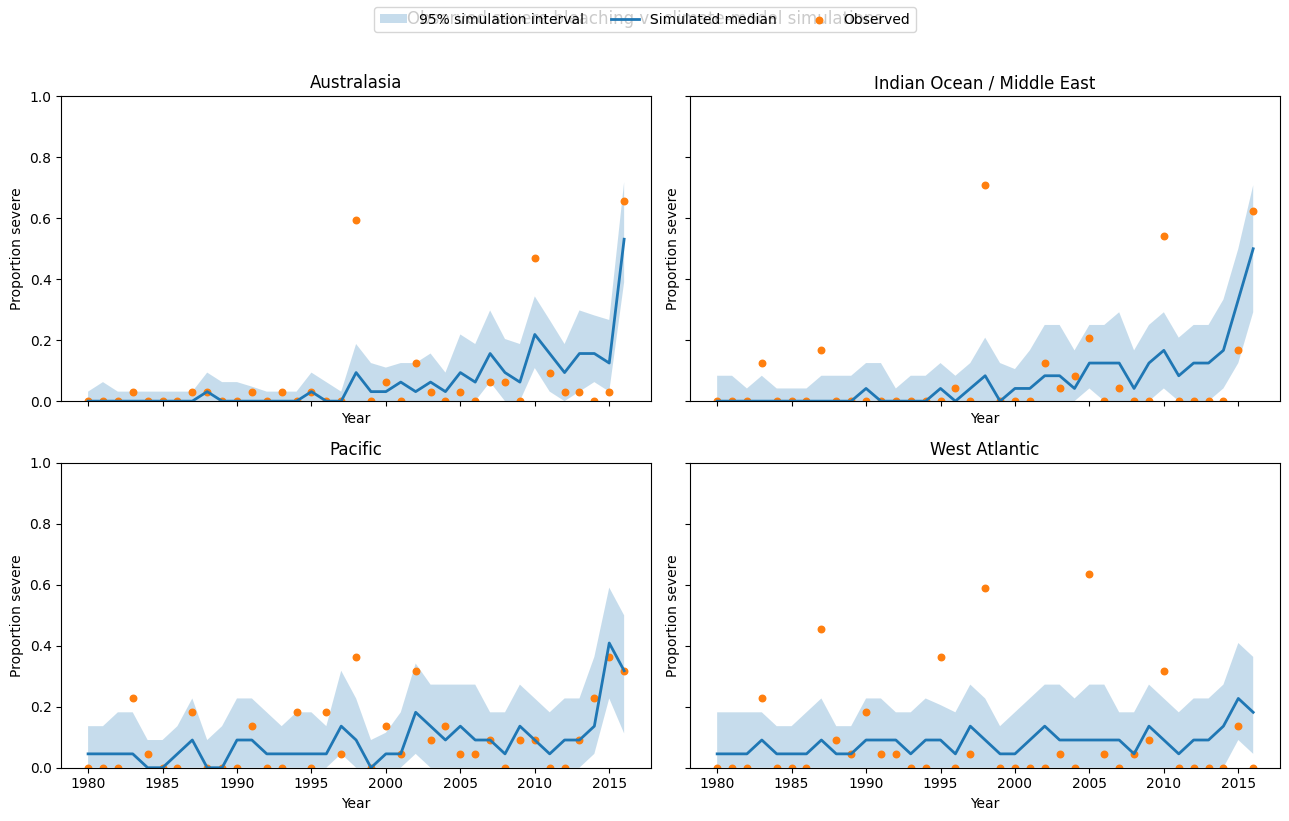

In [ ]:
fig, axes = plt.subplots(
    2, 2, figsize=(13, 8),
    sharex=True, sharey=True
)

axes = axes.flatten()

for ax, region in zip(axes, regions):
    d = plot_data[plot_data["region"] == region]

    ax.fill_between(
        d["year"], d["lower"], d["upper"],
        alpha=0.25, label="95% simulation interval"
    )

    ax.plot(
        d["year"], d["median"],
        linewidth=2, label="Simulated median"
    )

    ax.scatter(
        d["year"], d["observed"],
        s=22, label="Observed"
    )

    ax.set_title(region)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Year")
    ax.set_ylabel("Proportion severe")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.suptitle(
    "Observed severe bleaching vs climate-model simulations",
    y=1.02
)

plt.tight_layout()
plt.show()

9. Simple model-checking summary

In [ ]:
plot_data["inside_95"] = (
    (plot_data["observed"] >= plot_data["lower"])
    & (plot_data["observed"] <= plot_data["upper"])
)

coverage_table = (
    plot_data.groupby("region")["inside_95"]
    .mean()
    .reset_index(name="fraction_inside_95_interval")
)

display(coverage_table)
print(
    "Overall fraction inside 95% interval:",
    round(plot_data["inside_95"].mean(), 3)
)

,region,fraction_inside_95_interval
0,Australasia,0.918919
1,Indian Ocean / Middle East,0.864865
2,Pacific,0.891892
3,West Atlantic,0.810811


Overall fraction inside 95% interval: 0.872


10. One parameter-recovery sanity check
Simulate a full dataset from known fitted parameters, refit it, and compare the recovered values with the generating values.

In [ ]:
y_original = y.copy()

recovery_rng = np.random.default_rng(12345)

synthetic = simulate_dataset_climate(
    master, a_hat, b_hat, c_hat, sigma_hat, recovery_rng
)

y = synthetic["simulated_severe"].to_numpy(dtype=int)

recovery_fit = minimize(
    climate_neg_loglik,
    theta_climate.copy(),
    method="BFGS",
    options={"maxiter": 1200, "gtol": 1e-5}
)

theta_recovered = recovery_fit.x

# Restore real observed data
y = y_original

recovery_table = pd.DataFrame({
    "parameter": (
        [f"{r}: intercept" for r in regions]
        + [f"{r}: temperature" for r in regions]
        + [f"{r}: nino" for r in regions]
        + ["reef SD"]
    ),
    "generating_value": np.concatenate([
        a_hat, b_hat, c_hat, [sigma_hat]
    ]),
    "recovered_value": np.concatenate([
        theta_recovered[0:R],
        theta_recovered[R:2*R],
        theta_recovered[2*R:3*R],
        [np.exp(theta_recovered[3*R])]
    ])
})

recovery_table["difference"] = (
    recovery_table["recovered_value"]
    - recovery_table["generating_value"]
)

print("Recovery fit success:", recovery_fit.success)
display(recovery_table)

Recovery fit success: False


,parameter,generating_value,recovered_value,difference
0,Australasia: intercept,-3.670398,-3.619914,0.050484
1,Indian Ocean / Middle East: intercept,-3.132560,-3.015058,0.117503
2,Pacific: intercept,-2.544340,-2.623739,-0.079399
3,West Atlantic: intercept,-2.384029,-2.570359,-0.186330
4,Australasia: temperature,7.778568,7.957619,0.179051
5,Indian Ocean / Middle East: temperature,5.964408,4.704954,-1.259455
6,Pacific: temperature,2.588071,3.549332,0.961261
7,West Atlantic: temperature,1.356134,0.771585,-0.584550
8,Australasia: nino,-1.005072,-0.982983,0.022089
9,Indian Ocean / Middle East: nino,-0.079198,0.125586,0.204783


The climate GLMM provided a substantially better fit to the observed severe-bleaching data than the paper-like time GLMM. The climate model had an AIC of 1822.1 compared with 1984.9 for the time model, and a BIC of 1903.0 compared with 2040.8. Thus, the improvement in likelihood was large enough to outweigh the additional parameters in the climate model.
The fitted climate model estimated positive effects of global temperature anomaly in all four regions, suggesting that increasing global temperature is associated with increasing severe-bleaching probability. Niño 3.4 effects were weaker and differed among regions, consistent with the exploratory analysis.
Forward Monte Carlo simulations reproduced the broad pattern of increasing severe bleaching and much of the regional variation. Overall, 87.2% of observed region-year bleaching proportions fell inside the model's simulated 95% interval. However, several large observed bleaching events fell above the simulated range, particularly in some years in Australasia, the Indian Ocean/Middle East, and the West Atlantic. Therefore, the model captures the broad climatic trend but underestimates some extreme bleaching episodes.
In the parameter-recovery test, regional intercepts and several climate coefficients were recovered approximately from simulated data. However, the reef random-effect SD was not recovered: its generating value was approximately 0.265, while the refitted value was close to zero. The recovery optimizer also did not report formal convergence. This suggests that the relatively small reef-level variance is difficult to identify from a single simulated realization and should be interpreted cautiously.

Conclusion. The original analysis modeled severe coral bleaching as increasing with calendar time. We tested a small extension in which calendar time was replaced by global temperature anomaly and annual mean Niño 3.4 anomaly while retaining a reef-specific random intercept. The climate GLMM fit the observed data substantially better than the paper-like time model (AIC 1822.1 vs. 1984.9; BIC 1903.0 vs. 2040.8). Forward simulations reproduced most of the broad regional and temporal pattern, with 87.2% of region-year observations falling within the simulated 95% envelope, but underestimated several extreme bleaching events. This suggests that measured climate variables explain more of the observed bleaching pattern than calendar time alone, while important local and short-term drivers of mass bleaching remain unmodeled.

Parameter recovery was reasonable for several fixed effects but poor for the relatively small reef random-effect variance, indicating uncertainty in estimating reef-level heterogeneity.